# Laboratorio 9: sesgo, varianza y el precio de restringir

Un polinomio de grado 19 ajustado sobre 20 observaciones pasa exactamente por las 20 y falla
por un factor de siete millones sobre datos nuevos.

<p align="center">
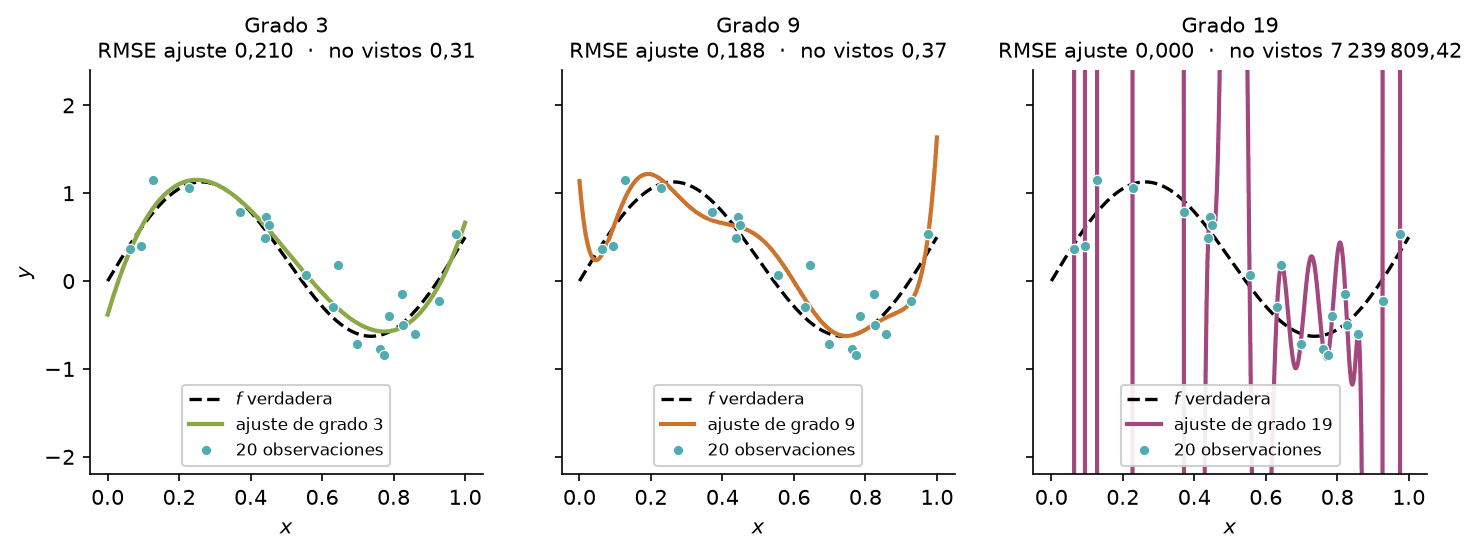
</p>

*Los mismos veinte puntos ajustados con tres familias de funciones. El error de ajuste baja
siempre; el error sobre datos no vistos tiene un mínimo y después explota. Las tres cifras y
las tres curvas se reproducen en la sección 0 de este notebook, con la misma semilla.*

El error esperado sobre una observación nueva se divide en tres,

$$
\mathbb{E}\bigl[(y_0-\hat f(x_0))^2\bigr]
\;=\;
\underbrace{\bigl(\bar f(x_0)-f(x_0)\bigr)^2}_{\text{Sesgo}^2}
\;+\;
\underbrace{\mathbb{E}\bigl[(\hat f(x_0)-\bar f(x_0))^2\bigr]}_{\text{Varianza}}
\;+\;
\underbrace{\sigma^2}_{\text{Irreducible}} .
$$

Este laboratorio mide este error: sobre una simulación con verdad conocida se estiman las tres piezas por separado y se verifica que su
suma coincide con el error esperado estimado **por un camino independiente**, que no comparte una sola línea de código con el primero.

## Cómo está organizado

| Sección | Qué se hace | Ejercicio |
|---|---|---|
| 0 | El proceso generador y **los 20 puntos**: subir el grado y ver aparecer el sobreajuste | — |
| 1 | **Medir** sesgo, varianza y error irreducible, y verificar la identidad | **1** |
| 2 | Curvas de aprendizaje: el diagnóstico que sí se construye con un solo conjunto | — |
| 3 | **Ridge desde cero** por su forma cerrada, y el número de condición | **2** y **3** |
| 4 | El **caso ortonormal**: encogimiento proporcional contra umbral suave | **4** |
| 5 | La misma medición de la sección 1, ahora moviendo $\lambda$ en lugar del grado | **5** |
| 6 | Datos reales: dónde penalizar paga y dónde no | DECIDE final |

**Cinco celdas llevan `raise NotImplementedError()` y deben completarse. Ninguna pasa de cinco líneas**: son fórmulas de la clase escritas en `numpy`.

| # | Qué se escribe | De dónde sale |
|---|---|---|
| 1 | `descomponer` | Las definiciones de sesgo y varianza |
| 2 | `ridge_desde_cero` | La forma cerrada $(\mathbf{X}^\top\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ |
| 3 | `numero_condicion` | $\kappa(\lambda)=(d_{\max}+\lambda)/(d_{\min}+\lambda)$ |
| 4 | `soft_umbral` | El umbral suave del caso ortonormal |
| 5 | `simular_penalizado` | Las dos cosas anteriores, juntas |

## 0. Preparación

La celda siguiente importa lo que el laboratorio necesita y fija la paleta del curso. La
semilla se declara una sola vez, en `SEMILLA`, y **toda celda con aleatoriedad la usa**: sin
eso las cifras cambian en cada ejecución y ninguna verificación significa nada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

SEMILLA = 42

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

print("Entorno listo.")

Entorno listo.


### El proceso que genera los datos

La descomposición involucra dos cantidades que **ninguna muestra permite calcular**:

- $f$, la función verdadera. En un problema real es justamente lo que se quiere estimar.
- $\bar f$, la predicción media **sobre todos los conjuntos de entrenamiento posibles**.

La verificación de la identidad se hace sobre una simulación y no sobre datos reales: acá se conocen las dos. El proceso es

$$
y_i \;=\; f(x_i) + \varepsilon_i,
\qquad
f(x) = \sin(2\pi x) + 0{,}5\,x,
\qquad
\varepsilon_i \sim \mathcal{N}(0,\sigma^2),
\quad \sigma = 0{,}30 ,
$$

con $x_i$ uniformes en $[0,1]$. **El error irreducible es conocido y vale $\sigma^2 = 0{,}09$**:
es la cota que ningún modelo baja, ni con más datos, ni con más atributos, ni con una familia
más rica.

Las tres funciones de la celda siguiente vienen resueltas. Conviene leer el comentario de `ajustar_polinomio`: la elección de la base no es trivial.

In [2]:
def f_verdadera(x: np.ndarray) -> np.ndarray:
    """La función que genera los datos. En un problema real es desconocida."""
    return np.sin(2 * np.pi * x) + 0.5 * x


SIGMA = 0.30


def generar_muestra(n: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Sortea n observaciones del proceso: x uniforme en [0, 1] y ruido gaussiano.

    Devuelve
    --------
    (x, y) : dos arrays de forma (n,)
    """
    x = rng.uniform(0, 1, n)
    return x, f_verdadera(x) + rng.normal(0, SIGMA, n)


def ajustar_polinomio(x: np.ndarray, y: np.ndarray, grado: int):
    """Ajusta un polinomio por mínimos cuadrados y devuelve la función ajustada.

    Se usa la base de Chebyshev sobre el dominio reescalado, y no la de monomios
    crudos. Con potencias de x el sistema queda tan mal condicionado que el ajuste
    de grado alto ni siquiera llega a interpolar: el fenómeno que interesa medir
    quedaría tapado por el error numérico, y se estaría midiendo la aritmética de
    punto flotante en lugar de la varianza del estimador.
    """
    return np.polynomial.Chebyshev.fit(x, y, deg=grado, domain=[0, 1])


print("f(x) = sin(2 pi x) + 0,5 x")
print(f"sigma = {SIGMA}     sigma^2 = {SIGMA ** 2:.4f}   <- la cota inferior del error")

f(x) = sin(2 pi x) + 0,5 x
sigma = 0.3     sigma^2 = 0.0900   <- la cota inferior del error


### Los veinte puntos

Todo el laboratorio gira alrededor de un único conjunto de **20 observaciones**, generado una sola vez. Este conjunto de datos es chico: con 20 puntos, un polinomio de grado 19 tiene 20 coeficientes y 20 ecuaciones, de modo que **puede pasar exactamente por las 20 observaciones**.

Se genera además un conjunto de 400 observaciones nuevas del **mismo proceso**, que no participa de ningún ajuste (son para evaluar el entrenamiento). Es la única forma honesta de medir qué tan bien predice cada modelo: el error sobre los mismos datos con los que se ajustó no responde esa pregunta.

In [3]:
rng = np.random.default_rng(SEMILLA)

# El conjunto de ajuste: 20 observaciones, ordenadas para poder graficarlas
x_aj = np.sort(rng.uniform(0, 1, 20))
y_aj = f_verdadera(x_aj) + rng.normal(0, SIGMA, 20)

# Datos nuevos del mismo proceso, que no participan de ningún ajuste
x_nv = np.linspace(0, 1, 400)
y_nv = f_verdadera(x_nv) + rng.normal(0, SIGMA, len(x_nv))

print(f"conjunto de ajuste: {len(x_aj)} observaciones")
print(f"datos nuevos:       {len(x_nv)} observaciones del mismo proceso")

conjunto de ajuste: 20 observaciones
datos nuevos:       400 observaciones del mismo proceso


### Subir el grado

Sobre esas 20 observaciones se ajustan polinomios de grado creciente. **Es el experimento de la figura de la portada**.

La tabla contrapone dos cifras que suelen confundirse:

- el **error de ajuste**, calculado sobre las mismas 20 observaciones que se usaron para ajustar;
- el **error sobre datos nuevos**, calculado sobre las 400 observaciones que el modelo no vio.

Ambos en RMSE, es decir en las unidades de $y$, para poder compararlos contra $\sigma = 0{,}30$.

In [4]:
GRADOS_VISTA = [1, 3, 5, 9, 15, 19]

print(f"{'grado':>6} {'RMSE de ajuste':>16} {'RMSE datos nuevos':>20}")
for g in GRADOS_VISTA:
    modelo = ajustar_polinomio(x_aj, y_aj, g)
    rmse_ajuste = np.sqrt(mean_squared_error(y_aj, modelo(x_aj)))
    rmse_nuevos = np.sqrt(mean_squared_error(y_nv, modelo(x_nv)))
    print(f"{g:>6} {rmse_ajuste:>16.6f} {rmse_nuevos:>20.4f}")

print(f"\nerror irreducible: sigma = {SIGMA:.4f}")

 grado   RMSE de ajuste    RMSE datos nuevos
     1         0.437496               0.5153
     3         0.209525               0.3076
     5         0.203825               0.3358
     9         0.187751               0.3749
    15         0.102367             684.8719
    19         0.000000         7239809.5683

error irreducible: sigma = 0.3000


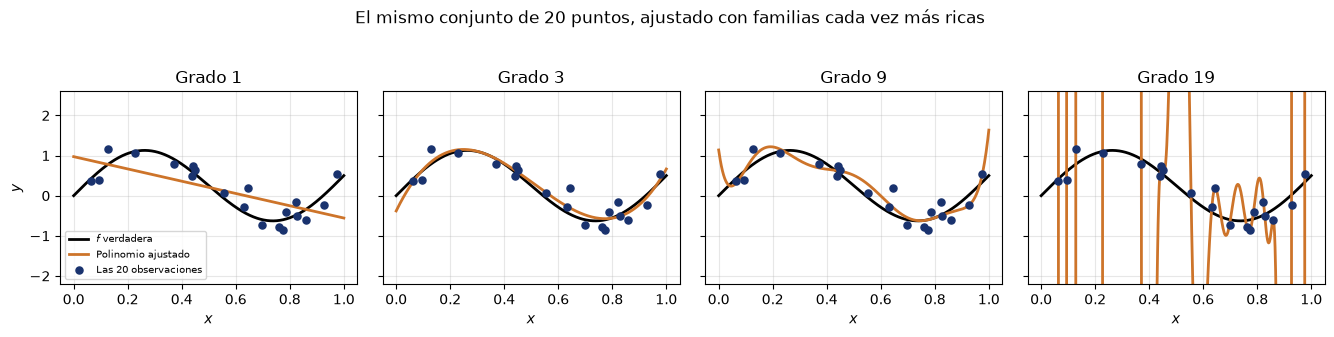

In [5]:
rejilla = np.linspace(0, 1, 500)
fig, ejes = plt.subplots(1, 4, figsize=(13.5, 3.2), sharey=True)

for eje, g in zip(ejes, [1, 3, 9, 19]):
    modelo = ajustar_polinomio(x_aj, y_aj, g)
    eje.plot(rejilla, f_verdadera(rejilla), color="black", lw=2, label="$f$ verdadera")
    eje.plot(rejilla, modelo(rejilla), color=NARANJA, lw=2, label="Polinomio ajustado")
    eje.scatter(x_aj, y_aj, color=AZUL, s=26, zorder=3, label="Las 20 observaciones")
    eje.set_ylim(-2.2, 2.6)
    eje.set_xlabel("$x$")
    eje.set_title(f"Grado {g}")
ejes[0].set_ylabel("$y$")
ejes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("El mismo conjunto de 20 puntos, ajustado con familias cada vez más ricas", y=1.04)
fig.tight_layout()
plt.show()

La columna izquierda de la tabla **decrece sin excepción** y llega a cero exacto en grado 19: el
polinomio interpola. La columna derecha tiene un mínimo en grado 3 y después explota, hasta
$7\times10^{6}$.

Dos lecturas que conviene fijar antes de seguir:

1. **Un error de ajuste por debajo de $\sigma$ no es un modelo mejor.** El grado 15 alcanza
   $0{,}102$ de error de ajuste, un tercio de $\sigma$. Ninguna función de $x$ puede predecir
   estas observaciones con error medio menor que $0{,}30$, porque esa parte del valor observado
   **no depende de $x$**. Bajar de ahí solo significa que el modelo absorbió ruido.
2. **La figura muestra por qué.** El polinomio de grado 19 pasa por los 20 puntos a costa de
   oscilar violentamente entre ellos. Entre dos observaciones vecinas hace lo que quiere,
   porque ahí no hay nada que lo sujete.

Falta la pregunta que abre el resto del laboratorio: **el error sobre datos nuevos empeora,
pero ¿por qué?** La tabla dice que empeora, no de qué está hecho ese empeoramiento. La
descomposición dice que está hecho de tres partes, y la sección 1 las mide una por una.

---

# 1. Medir las tres partes

## Qué se va a medir, y con qué

La identidad tiene tres términos y cada uno se consigue de una forma distinta:

| Término | Qué es | Cómo se obtiene acá |
|---|---|---|
| $\sigma^2$ | Varianza del ruido | **No se estima**: es conocido, vale $0{,}09$ |
| $\text{Sesgo}^2$ | Cuánto se desvía la predicción **media** de la verdad | Hace falta $\bar f$, o sea muchos conjuntos de entrenamiento |
| Varianza | Cuánto se mueve la predicción **de conjunto a conjunto** | Lo mismo |

Los dos últimos exigen algo que en la práctica no se tiene: **muchos conjuntos de entrenamiento del mismo proceso**. La simulación los produce.

## El procedimiento

1. Se generan $B = 500$ **conjuntos de entrenamiento independientes**, de $n = 40$ observaciones cada uno. Cada conjunto da lugar a un modelo distinto: son 500 modelos.
2. Los 500 modelos se evalúan en los **mismos 100 puntos de prueba** $x_0$, que están fijos y no se resortean nunca. El resultado es una matriz de $500 \times 100$ predicciones.
3. Sobre esa matriz se calculan las dos estimaciones. **La columna $j$ contiene las 500 predicciones en el punto $x_0[j]$**: ahí es donde vive la varianza.

$$
\bar f(x_0) \approx \frac{1}{B}\sum_{b=1}^{B}\hat f_b(x_0),
\qquad
\text{Sesgo}^2 \approx \overline{\bigl(\bar f(x_0)-f(x_0)\bigr)^2},
\qquad
\text{Var} \approx \overline{\operatorname{Var}_b\bigl(\hat f_b(x_0)\bigr)},
$$

donde la barra superior promedia sobre los 100 puntos de prueba.

> **Por qué $n=40$ y no los 20 puntos de la sección 0.** La sección 0 usa un conjunto fijo porque
> su objeto es mirar un ajuste concreto. Acá el conjunto de entrenamiento es **aleatorio por
> construcción**: la varianza que se quiere medir es la dispersión que produce cambiarlo.

La celda siguiente hace el sorteo y el ajuste, y viene resuelta: es andamiaje. Conviene leerla,
porque la forma de lo que devuelve es lo que el ejercicio 1 necesita entender.

In [6]:
B = 500                              # conjuntos de entrenamiento sorteados
N_SIM = 40                           # observaciones por conjunto
x0 = np.linspace(0.05, 0.95, 100)    # puntos de prueba, FIJOS
f0 = f_verdadera(x0)                 # la verdad en esos puntos: acá se conoce


def simular(grado: int, rng: np.random.Generator,
            B: int = B, n: int = N_SIM) -> np.ndarray:
    """Ajusta B modelos del mismo grado, cada uno sobre su propio conjunto sorteado.

    Devuelve
    --------
    (B, 100) : la fila b son las predicciones del modelo b en los 100 puntos x0.
        El grado 0 es el modelo sin atributos: predice la media de y, la misma
        en los 100 puntos.
    """
    predicciones = np.empty((B, len(x0)))
    for b in range(B):
        x, y = generar_muestra(n, rng)
        if grado == 0:
            predicciones[b] = np.full(len(x0), y.mean())
        else:
            predicciones[b] = ajustar_polinomio(x, y, grado)(x0)
    return predicciones


P = simular(3, np.random.default_rng(SEMILLA))
print(f"P: {P.shape}   ->  {P.shape[0]} modelos x {P.shape[1]} puntos de prueba")
print(f"predicciones en x0[0] de los tres primeros modelos: {P[:3, 0]}")
print("Las tres difieren: cada modelo se ajustó sobre un conjunto distinto.")

P: (500, 100)   ->  500 modelos x 100 puntos de prueba
predicciones en x0[0] de los tres primeros modelos: [0.4017 0.3342 0.0877]
Las tres difieren: cada modelo se ajustó sobre un conjunto distinto.


### Ejercicio 1: la descomposición

Con la matriz de predicciones en la mano, corresponde escribir las dos definiciones de la clase
en `numpy`. Son **dos líneas**, y el tercer término no se calcula porque $\sigma^2$ es conocido.

$$
\text{Sesgo}^2 \;=\; \overline{\bigl(\bar f - f\bigr)^2},
\qquad
\text{Var} \;=\; \overline{\operatorname{Var}_b(\hat f_b)} ,
\qquad
\bar f \;=\; \text{promedio de las } B \text{ filas}.
$$

**Lo único que hay que decidir es sobre qué eje se promedia**, y es todo el ejercicio:

- `predicciones.mean(axis=0)` promedia las **500 réplicas** y deja **100 valores**, uno por punto
  de prueba. Eso es $\bar f$.
- `predicciones.mean(axis=1)` promediaría los 100 puntos y dejaría 500 valores, que no es ninguna
  cantidad de la descomposición.

Si el resultado intermedio no tiene forma `(100,)`, el eje está equivocado.

**El orden importa en la varianza.** Primero la varianza **en cada punto** sobre las 500
réplicas (`predicciones.var(axis=0)`, que también deja 100 valores) y recién después el promedio
de esos 100 números. Invertir el orden da la variación de $\bar f$ a lo largo de $x$, que no
aparece en la identidad.

In [7]:
def descomponer(predicciones: np.ndarray, verdad: np.ndarray) -> tuple[float, float]:
    """Estima el sesgo al cuadrado y la varianza a partir de las predicciones.

    Parámetros
    ----------
    predicciones : (B, m) predicciones de los B modelos en los m puntos de prueba
    verdad       : (m,)   f(x0), el valor verdadero en cada punto de prueba

    Devuelve
    --------
    (sesgo2, varianza) : los dos promediados sobre los m puntos de prueba
    """
    prediccion_media = predicciones.mean(axis=0)
    sesgo2 = np.mean((prediccion_media - verdad) ** 2)
    varianza = np.mean(predicciones.var(axis=0))
    return float(sesgo2), float(varianza)

### Verificación

- **Camino A.** `descomponer` estima $\text{Sesgo}^2$ y $\text{Var}$ a partir de la matriz de
  predicciones, y se les suma el $\sigma^2$ conocido.
- **Camino B.** `error_esperado_directo` no usa la descomposición sino que genera una
  observación nueva $y_0 = f(x_0)+\varepsilon_0$ para cada réplica y cada punto, y promedia
  $(y_0-\hat f)^2$.

La comparación corre con `rtol=0.05`, es decir 5 % de tolerancia relativa. Las dos cifras son **estimaciones** a partir de 500 réplicas, y difieren entre sí por error de simulación aunque la identidad sea exacta.

In [8]:
def error_esperado_directo(predicciones: np.ndarray, verdad: np.ndarray,
                           rng: np.random.Generator) -> float:
    """Estima E[(y0 - f_hat)^2] directamente, sin pasar por la descomposición."""
    y0 = verdad[None, :] + rng.normal(0, SIGMA, predicciones.shape)
    return float(np.mean((y0 - predicciones) ** 2))


# VERIFICACIÓN
rv = np.random.default_rng(SEMILLA)
Pv = simular(3, rv)
s2, var = descomponer(Pv, f0)
directo = error_esperado_directo(Pv, f0, rv)

print(f"CAMINO A   sesgo^2 = {s2:.4f}   varianza = {var:.4f}   sigma^2 = {SIGMA ** 2:.4f}")
print(f"           suma de los tres        = {s2 + var + SIGMA ** 2:.4f}")
print(f"CAMINO B   error esperado, directo = {directo:.4f}")
assert np.isclose(s2 + var + SIGMA ** 2, directo, rtol=0.05)
print("\nLas dos cifras coinciden. La identidad se verifica.")

CAMINO A   sesgo^2 = 0.0034   varianza = 0.0088   sigma^2 = 0.0900
           suma de los tres        = 0.1023
CAMINO B   error esperado, directo = 0.1025

Las dos cifras coinciden. La identidad se verifica.


### La tabla completa

Lo anterior verificó la identidad en un solo grado. La tabla la verifica en nueve, y de paso
exhibe el compromiso: cómo se mueven los dos términos cuando la familia de funciones se
enriquece.

In [9]:
grados = [0, 1, 2, 3, 5, 7, 9, 12, 15]
rs = np.random.default_rng(SEMILLA)
tabla = {}

print(f"{'grado':>6} {'Sesgo^2':>10} {'Varianza':>12} {'sigma^2':>10} "
      f"{'suma (A)':>12} {'directo (B)':>14}")
for g in grados:
    Pg = simular(g, rs)
    s2_g, var_g = descomponer(Pg, f0)
    directo_g = error_esperado_directo(Pg, f0, rs)
    tabla[g] = (s2_g, var_g, s2_g + var_g + SIGMA ** 2, directo_g)
    print(f"{g:>6} {s2_g:>10.4f} {var_g:>12.4f} {SIGMA ** 2:>10.4f} "
          f"{s2_g + var_g + SIGMA ** 2:>12.4f} {directo_g:>14.4f}")

mejor = min(tabla, key=lambda g: tabla[g][2])
print(f"\ngrado que minimiza la suma: {mejor}   "
      f"(suma {tabla[mejor][2]:.4f}, contra la cota sigma^2 = {SIGMA ** 2:.4f})")
print(f"fracción irreducible del error del mejor modelo: "
      f"{100 * SIGMA ** 2 / tabla[mejor][2]:.0f} %")

 grado    Sesgo^2     Varianza    sigma^2     suma (A)    directo (B)
     0     0.3962       0.0118     0.0900       0.4980         0.5007
     1     0.1540       0.0161     0.0900       0.2601         0.2625
     2     0.1474       0.0280     0.0900       0.2654         0.2688
     3     0.0034       0.0084     0.0900       0.1018         0.1014
     5     0.0000       0.0136     0.0900       0.1037         0.1037
     7     0.0000       0.0235     0.0900       0.1135         0.1132
     9     0.0005       0.2481     0.0900       0.3386         0.3394
    12     0.0179      14.9559     0.0900      15.0638        15.0597
    15     0.0662     144.8310     0.0900     144.9872       144.9961

grado que minimiza la suma: 3   (suma 0.1018, contra la cota sigma^2 = 0.0900)
fracción irreducible del error del mejor modelo: 88 %


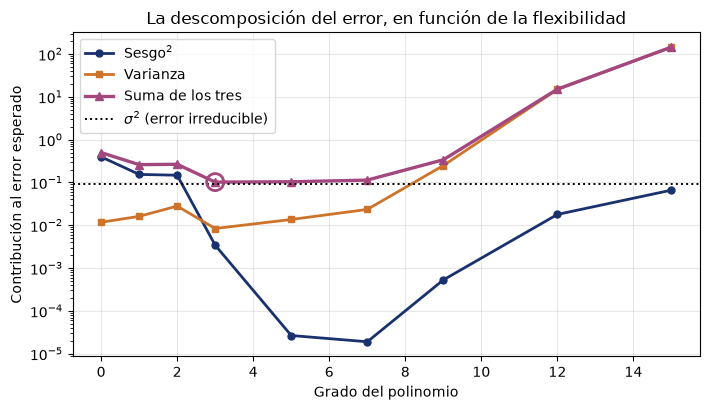

In [10]:
fig, eje = plt.subplots(figsize=(7.2, 4.2))
eje.plot(grados, [tabla[g][0] for g in grados], "o-", color=AZUL,
         lw=2, ms=5, label="Sesgo$^2$")
eje.plot(grados, [tabla[g][1] for g in grados], "s-", color=NARANJA,
         lw=2, ms=5, label="Varianza")
eje.plot(grados, [tabla[g][2] for g in grados], "^-", color=VIOLETA,
         lw=2.4, ms=6, label="Suma de los tres")
eje.axhline(SIGMA ** 2, color="black", ls=":", lw=1.4,
            label=r"$\sigma^2$ (error irreducible)")
eje.scatter([mejor], [tabla[mejor][2]], s=150, facecolor="none",
            edgecolor=VIOLETA, lw=2, zorder=5)
eje.set_yscale("log")
eje.set_xlabel("Grado del polinomio")
eje.set_ylabel("Contribución al error esperado")
eje.set_title("La descomposición del error, en función de la flexibilidad")
eje.legend()
fig.tight_layout()
plt.show()

### Para analizar

1. El sesgo al cuadrado **deja de bajar** entre el grado 5 y el 15, mientras la varianza sigue
   creciendo. ¿Qué tiene el polinomio de grado 5 que hace que agregar términos ya no reduzca
   sesgo?
2. El grado que minimiza la suma **no minimiza ninguno de los dos términos por separado**. Decir
   qué grado minimiza el sesgo, cuál la varianza y cuál la suma, y explicar en una oración por
   qué el óptimo no se encuentra optimizando uno solo.
3. La celda imprime qué fracción del error del mejor modelo es irreducible. **¿Qué margen de
   mejora deja eso?** ¿Serviría de algo cambiar de familia de funciones?

**Respuesta:**

1. El grado 5 ya es suficientemente flexible para aproximar casi sin error a $f(x)=\sin(2\pi x)+0{,}5x$ en $[0,1]$. Los términos adicionales prácticamente no reducen el sesgo de aproximación y empiezan a seguir el ruido de cada muestra, por lo que aumenta la varianza.
2. En la tabla, el grado 7 minimiza el sesgo$^2$ ($1{,}90\times10^{-5}$), mientras que el grado 3 minimiza tanto la varianza ($0{,}0084$) como la suma ($0{,}1018$). Por lo tanto, la afirmación de la consigna de que el grado óptimo no minimiza ninguno de los dos términos no coincide con esta simulación: sí coincide con el mínimo de varianza. La idea general se mantiene: hay que minimizar la suma, no cada componente por separado.
3. El $88\%$ del error del mejor modelo es irreducible, así que aun eliminando todo el sesgo y toda la varianza sólo queda un margen máximo cercano al $12\%$. Cambiar de familia aportaría muy poco: el sesgo del grado 3 ya es pequeño y la mayor parte del error proviene del ruido.

---

# 2. Curvas de aprendizaje

La sección 1 midió la descomposición con 500 conjuntos de entrenamiento. **Con datos reales se
tiene uno solo**, y la pregunta práctica es qué diagnóstico se puede construir con eso.

La respuesta es la **curva de aprendizaje**: se contraponen el error de ajuste y el error sobre
datos no vistos, ambos en función de la **cantidad de observaciones empleadas**. No estima sesgo
ni varianza por separado, pero la forma relativa de las dos curvas (si convergen, a qué altura y
si queda brecha) alcanza para decidir qué corresponde hacer.

| Qué se observa | Qué indica | Qué corresponde |
|---|---|---|
| Las dos curvas convergen **por encima de $\sigma^2$** | Subajuste: el error viene de la forma, no de la estimación | Enriquecer la familia, agregar atributos, reducir la penalización |
| Queda una **brecha persistente** entre las dos | Sobreajuste: el modelo se ajusta a lo que no se repite | Más observaciones, familia más restringida, penalizar |
| Las dos curvas convergen **sobre $\sigma^2$** | El modelo alcanzó el techo | Nada por hacer con estos atributos |
| El error de ajuste está **por debajo de $\sigma^2$** | El modelo absorbió ruido | Restringir, sin excepción |

La celda siguiente construye las dos curvas y viene resuelta. **El trabajo de esta sección es
leerlas**, en el bloque DECIDE.

> **Un detalle de la implementación, que conviene mirar.** El error de ajuste se resume con la
> media y el error sobre datos nuevos con la **mediana**. No es una inconsistencia: en los grados
> altos con muestras chicas alguna réplica produce un error de $10^{6}$ o más, y una sola de esas
> se lleva puesto el promedio de las 200. La mediana deja ver la curva típica en lugar del peor
> caso.

In [11]:
# El conjunto de datos nuevos de esta sección: fijo, y ajeno a todos los ajustes
x_nuevos = np.linspace(0.02, 0.98, 400)
rn = np.random.default_rng(SEMILLA)
y_nuevos = f_verdadera(x_nuevos) + rn.normal(0, SIGMA, len(x_nuevos))

TAMANOS = np.array([15, 20, 25, 30, 40, 55, 75, 100, 140, 200, 300])


def curva_aprendizaje(grado: int, tamanos: np.ndarray, rng: np.random.Generator,
                      R: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Error de ajuste y error sobre datos nuevos, en función del tamaño de muestra.

    Devuelve
    --------
    (err_ajuste, err_nuevos) : dos arrays (T,). El primero promedia sobre las R
        réplicas; el segundo toma la mediana
    """
    err_ajuste = np.empty(len(tamanos))
    err_nuevos = np.empty(len(tamanos))
    for i, t in enumerate(tamanos):
        ajuste_r = np.empty(R)
        nuevos_r = np.empty(R)
        for r in range(R):
            x, y = generar_muestra(int(t), rng)
            modelo = ajustar_polinomio(x, y, grado)
            ajuste_r[r] = mean_squared_error(y, modelo(x))
            nuevos_r[r] = mean_squared_error(y_nuevos, modelo(x_nuevos))
        err_ajuste[i] = ajuste_r.mean()
        err_nuevos[i] = np.median(nuevos_r)
    return err_ajuste, err_nuevos


print(f"tamaños a probar: {TAMANOS}")

tamaños a probar: [ 15  20  25  30  40  55  75 100 140 200 300]


Grado 1:  n=15  -> ajuste 0.2392, nuevos 0.2692
          n=300 -> ajuste 0.2817, nuevos 0.2429
Grado 12:  n=15  -> ajuste 0.0125, nuevos 36800.2486
           n=300 -> ajuste 0.0858, nuevos 0.0847


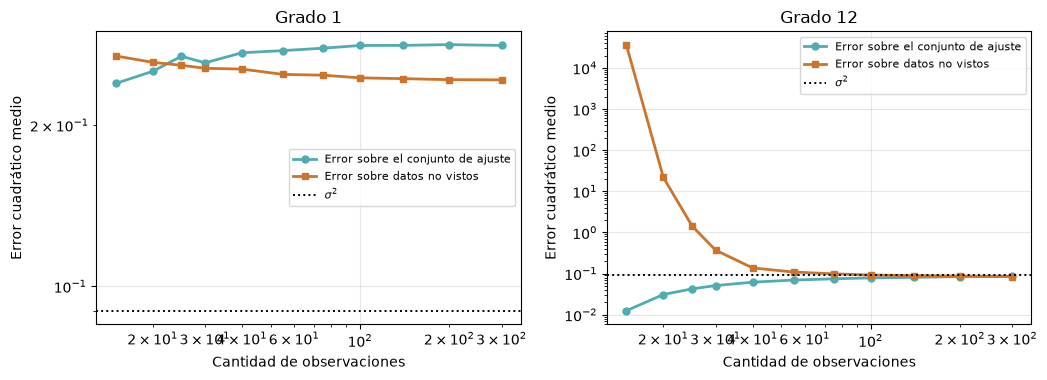

In [12]:
rl = np.random.default_rng(SEMILLA)
fig, ejes = plt.subplots(1, 2, figsize=(10.6, 3.9))

for eje, g, rotulo in [(ejes[0], 1, "Grado 1"), (ejes[1], 12, "Grado 12")]:
    e_aj, e_nv = curva_aprendizaje(g, TAMANOS, rl)
    eje.plot(TAMANOS, e_aj, "o-", color=TURQUESA, lw=2, ms=5,
             label="Error sobre el conjunto de ajuste")
    eje.plot(TAMANOS, e_nv, "s-", color=NARANJA, lw=2, ms=5,
             label="Error sobre datos no vistos")
    eje.axhline(SIGMA ** 2, color="black", ls=":", lw=1.4, label=r"$\sigma^2$")
    eje.set_xscale("log")
    eje.set_yscale("log")
    eje.set_xlabel("Cantidad de observaciones")
    eje.set_ylabel("Error cuadrático medio")
    eje.set_title(rotulo)
    eje.legend(fontsize=8)
    print(f"{rotulo}:  n=15  -> ajuste {e_aj[0]:.4f}, nuevos {e_nv[0]:.4f}")
    print(f"{' ' * len(rotulo)}   n=300 -> ajuste {e_aj[-1]:.4f}, nuevos {e_nv[-1]:.4f}")

fig.tight_layout()
plt.show()

### DECIDE

A partir de las dos figuras, de las cifras impresas y del cuadro de diagnóstico de más arriba:

1. En el panel de grado 12 con 15 observaciones, el error de ajuste vale $0{,}0125$ y
   $\sigma^2$ vale $0{,}09$. **¿Qué significa que el error de ajuste esté por debajo del
   ruido**, y qué fila del cuadro cubre esa situación?
2. La curva del error de ajuste **crece** con $n$ y la de datos no vistos **decrece**. Explicar
   las dos cosas por separado, y decir qué se concluiría si las dos curvas nunca llegaran a
   juntarse.

**Respuesta:**

1. Significa que el modelo está ajustando parte del ruido particular de esas 15 observaciones: logró un MSE de ajuste de $0{,}0125$, imposible de sostener frente a la cota esperada $\sigma^2=0{,}09$ en datos nuevos. Corresponde a la fila «el error de ajuste está por debajo de $\sigma^2$»: hay sobreajuste y se debe restringir el modelo.
2. Al aumentar $n$, cada ajuste debe satisfacer más observaciones y tiene menos libertad para interpolar sus peculiaridades, por eso sube el error de ajuste. A la vez, los coeficientes se estiman con más información, baja la varianza y disminuye el error sobre datos no vistos. Si persistiera una brecha entre ambas curvas, el diagnóstico sería sobreajuste: harían falta más observaciones o una familia más restringida/penalizada.

---

# 3. Ridge

La sección 1 dejó el problema planteado en términos operativos: **hay que bajar varianza y se está dispuesto a pagar algo de sesgo a cambio**. Bajar la complejidad del modelo es una forma de hacerlo, pero es una decisión discreta y burda, y obliga a elegir la familia antes de ver los datos.

La alternativa es **no tocar la familia de funciones y cambiar el criterio con que se elige
dentro de ella**. Eso es regularizar.

## Un cambio de escenario

Hasta acá la perilla de complejidad fue el grado del polinomio, porque con una sola variable se puede dibujar lo que pasa. De acá en adelante se trabaja con **un problema de muchos atributos**, que es la forma en que el problema aparece en la práctica y donde la regularización se usa de verdad. La perilla de complejidad pasa a ser **cuántos coeficientes hay que estimar con cuántas observaciones**, que es la misma cantidad que la sección 1 identificó como responsable de la varianza.

Nada de lo derivado cambia. La matriz de diseño vuelve a ser exactamente la de la clase 3 (una fila por observación, una columna por atributo) y ahora las columnas son atributos medidos, sin ninguna transformación de por medio.

### El proceso

$$
y_i \;=\; \mathbf{x}_i^\top\boldsymbol\beta \;+\; \varepsilon_i,
\qquad
\varepsilon_i\sim\mathcal N(0,\sigma^2),\quad \sigma=1 .
$$

Hay **40 atributos** y sólo **5 importan**: los otros 35 tienen coeficiente verdadero cero. Es la
situación habitual cuando se miden muchas cosas sin saber de antemano cuáles sirven. Además, los
atributos 6 a 10 son **casi copias del atributo 1** (correlación $0{,}99$), que es la colinealidad
de la exposición: la superficie habitable y la suma de las dos plantas miden casi lo mismo.

El error irreducible vuelve a ser conocido: $\sigma^2=1$.

In [13]:
P_TOTAL = 40                 # atributos medidos
P_RELEVANTES = 5             # los que de verdad influyen
RHO = 0.99                   # correlación del bloque redundante con el atributo 1
SIGMA_TAB = 1.0              # desvío del ruido: sigma^2 = 1 es la cota

BETA_VERDADERO = np.zeros(P_TOTAL)
BETA_VERDADERO[:P_RELEVANTES] = [2.5, -2.0, 1.5, -1.0, 0.8]


def generar_atributos(n: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Sortea n observaciones del proceso de 40 atributos.

    Las columnas 6 a 10 (índices 5 a 9) son casi copias de la columna 1: es el
    bloque redundante, y es donde se va a ver la diferencia entre las dos
    penalizaciones.

    Devuelve
    --------
    (X, y) : (n, 40) y (n,)
    """
    X = rng.normal(0, 1, (n, P_TOTAL))
    for j in range(5, 10):
        X[:, j] = RHO * X[:, 0] + np.sqrt(1 - RHO ** 2) * rng.normal(0, 1, n)
    return X, X @ BETA_VERDADERO + rng.normal(0, SIGMA_TAB, n)


print(f"atributos: {P_TOTAL}   con coeficiente no nulo: {P_RELEVANTES}")
print(f"beta verdadero de los cinco primeros: {BETA_VERDADERO[:P_RELEVANTES]}")
print(f"los otros {P_TOTAL - P_RELEVANTES} valen exactamente cero")
print(f"sigma^2 = {SIGMA_TAB ** 2:.2f}   <- la cota inferior del error")

atributos: 40   con coeficiente no nulo: 5
beta verdadero de los cinco primeros: [ 2.5 -2.   1.5 -1.   0.8]
los otros 35 valen exactamente cero
sigma^2 = 1.00   <- la cota inferior del error


### El caso perdido

Se genera **un** conjunto de 45 observaciones. Con 40 atributos, eso deja $n/p = 1{,}12$. Es el análogo exacto del polinomio de grado 15 sobre 20 puntos, y también acá hay un conjunto de datos nuevos, grande, que no participa de ningún ajuste.

In [14]:
rng_tab = np.random.default_rng(SEMILLA)

X_tab, y_tab = generar_atributos(45, rng_tab)            # el conjunto de ajuste
X_tab_nv, y_tab_nv = generar_atributos(2000, rng_tab)    # datos nuevos, del mismo proceso

sin_penalizar = LinearRegression().fit(X_tab, y_tab)
mse_ajuste = mean_squared_error(y_tab, sin_penalizar.predict(X_tab))
mse_nuevos = mean_squared_error(y_tab_nv, sin_penalizar.predict(X_tab_nv))

print(f"conjunto de ajuste: {X_tab.shape[0]} observaciones x {X_tab.shape[1]} atributos")
print(f"n / p = {X_tab.shape[0] / X_tab.shape[1]:.2f}\n")
print(f"MSE sobre las 45 que vio : {mse_ajuste:.4f}   <- por debajo de sigma^2")
print(f"MSE sobre datos nuevos   : {mse_nuevos:.4f}")
print(f"sigma^2                  : {SIGMA_TAB ** 2:.4f}   <- la cota que nadie baja\n")
print(f"norma de los coeficientes: {np.linalg.norm(sin_penalizar.coef_):.4f}")
print(f"mayor coeficiente en valor absoluto: {np.abs(sin_penalizar.coef_).max():.4f}")
print(f"(el mayor coeficiente verdadero vale {np.abs(BETA_VERDADERO).max():.1f})")

conjunto de ajuste: 45 observaciones x 40 atributos
n / p = 1.12

MSE sobre las 45 que vio : 0.1355   <- por debajo de sigma^2
MSE sobre datos nuevos   : 14.6026
sigma^2                  : 1.0000   <- la cota que nadie baja

norma de los coeficientes: 9.0235
mayor coeficiente en valor absoluto: 5.4998
(el mayor coeficiente verdadero vale 2.5)


El diagnóstico es el mismo de la sección 0, en otro vestido: **el error de ajuste está por
debajo de $\sigma^2$ y el error sobre datos nuevos es catorce veces la cota.** El modelo absorbió ruido, y se ve en los coeficientes: el mayor vale más del doble que el mayor coeficiente verdadero, y hay 35 atributos que no influyen en nada a los que se les estimó un coeficiente distinto de cero.

## Agregar un término a la función de costo

$$
J^{R}(\boldsymbol{\beta})
\;=\;
\underbrace{\lVert\mathbf{y}-\mathbf{X}\boldsymbol{\beta}\rVert^2}_{\text{lo de siempre}}
\;+\;
\lambda\underbrace{\sum_{j=1}^{p}\beta_j^2}_{\text{el término nuevo}} ,
\qquad
\hat{\boldsymbol{\beta}}^{R}
=
(\mathbf{X}^\top\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y} .
$$

El primer término es **exactamente** la función de costo de mínimos cuadrados: la familia de
funciones no cambió, siguen siendo los mismos 40 coeficientes. Lo que cambia es cuál de todas las combinaciones posibles se elige. Con $\lambda = 0$ se recupera mínimos cuadrados; al crecer $\lambda$ los coeficientes se encogen y, en el límite, el modelo predice la media de $\mathbf{y}$.

**La suma arranca en $j=1$, por lo tanto, el intercepto no se penaliza.** No mide asociación con ningún atributo, sólo dónde está el origen de la escala de $y$; penalizarlo haría que la solución dependiera de esa escala.

**Siempre tiene solución.** $\mathbf{X}^\top\mathbf{X}$ es semidefinida positiva, y sumarle
$\lambda\mathbf{I}$ con $\lambda>0$ corre todos sus autovalores en $\lambda$: queda definida
positiva **sin ninguna hipótesis sobre el rango de $\mathbf{X}$**, y por lo tanto invertible aun con más columnas que observaciones. Con $n/p = 1{,}12$ eso deja de ser una nota al pie.

> **Convención del curso.** La función de costo va **sin $1/n$**, como quedó definida. Importa
> porque `scikit-learn` no normaliza igual en todas sus clases, y sin la traducción no se
> reproduce ninguna cuenta:
>
> | Clase | Qué minimiza | Traducción |
> |---|---|---|
> | `Ridge(alpha=a)` | $\lVert\mathbf{y}-\mathbf{X}\boldsymbol\beta\rVert^2+a\lVert\boldsymbol\beta\rVert_2^2$ | $a=\lambda$ |
> | `Lasso(alpha=a)` | $\frac{1}{2n}\lVert\mathbf{y}-\mathbf{X}\boldsymbol\beta\rVert^2+a\lVert\boldsymbol\beta\rVert_1$ | $a=\lambda/(2n)$ |
> | `LogisticRegression(C=c)` | Entropía cruzada penalizada | $c=1/\lambda$ |

## La matriz de diseño

Acá la matriz de diseño **son los datos**: `X_tab` ya es $\mathbf{X}$, con una fila por
observación y una columna por atributo. La única diferencia con la de la clase 3 es que **no
lleva la columna de unos**: el intercepto no se penaliza, así que no puede viajar adentro de la
matriz que sí se penaliza. Se lo recupera aparte, y la próxima celda explica cómo.

Sobre la estandarización: en este problema las columnas ya vienen en escalas comparables porque
el proceso las genera $\mathcal N(0,1)$. **En un problema real hay que estandarizar siempre**, y
la sección 6 lo hace, porque la penalización suma $\beta_j^2$ y un atributo medido en metros
cuadrados y otro en años quedarían penalizados con dureza muy distinta sin que eso tenga nada que
ver con su importancia.

In [15]:
print(f"matriz de diseño: {X_tab.shape[0]} observaciones x {X_tab.shape[1]} columnas")
print(f"n / p = {X_tab.shape[0] / X_tab.shape[1]:.2f}\n")
print("desvío de cada columna (las seis primeras):")
print(f"  {np.round(X_tab.std(axis=0)[:6], 3)}")
print("\nCorrelación del bloque redundante con el atributo 1:")
for j in range(5, 10):
    print(f"  atributo {j + 1:>2} contra atributo 1: {np.corrcoef(X_tab[:, 0], X_tab[:, j])[0, 1]:.3f}")

matriz de diseño: 45 observaciones x 40 columnas
n / p = 1.12

desvío de cada columna (las seis primeras):
  [0.896 0.915 1.115 0.887 0.913 0.877]

Correlación del bloque redundante con el atributo 1:
  atributo  6 contra atributo 1: 0.989
  atributo  7 contra atributo 1: 0.989
  atributo  8 contra atributo 1: 0.988
  atributo  9 contra atributo 1: 0.989
  atributo 10 contra atributo 1: 0.992


### Ejercicio 2: Ridge por su forma cerrada

La clase derivó la solución. Corresponde escribirla en `numpy`: son **cuatro líneas**.

**Pseudocódigo.**

```
x_medias = media de cada columna de X
y_media  = media de y
Xc = X - x_medias          (cada columna con media cero)
yc = y - y_media
resolver (Xc^T Xc + lambda * I) beta = Xc^T yc
intercepto = y_media - x_medias . beta
devolver (beta, intercepto)
```
- **Se centra, y no se agrega una columna de unos.** Si se agregara, el término
  $\lambda\lVert\boldsymbol{\beta}\rVert_2^2$ penalizaría también al intercepto. Centrando, el
  problema penalizado queda sin intercepto y se lo recupera al final con
  $\hat\beta_0=\bar y-\bar{\mathbf{x}}^\top\hat{\boldsymbol{\beta}}$.
- **Se usa `np.linalg.solve`, no `np.linalg.inv`.** Invertir para después multiplicar es más caro
  y numéricamente peor. La identidad se arma con `np.eye(p)`, donde `p` es la cantidad de
  **columnas**, porque vive en el espacio de los coeficientes.
- **El sistema siempre tiene solución**, por el argumento de los autovalores de más arriba.

In [16]:
def ridge_desde_cero(X: np.ndarray, y: np.ndarray,
                     lam: float) -> tuple[np.ndarray, float]:
    """Ridge por su forma cerrada, sin penalizar el intercepto.

    Minimiza  ||y - X beta||^2 + lam * ||beta||^2  sobre los datos centrados.

    Parámetros
    ----------
    X   : (n, p) matriz de diseño, SIN columna de unos
    y   : (n,)   respuesta
    lam : lambda, el parámetro de penalización

    Devuelve
    --------
    (beta, intercepto) : (p,) coeficientes y el escalar del intercepto
    """
    x_medias, y_media = X.mean(axis=0), y.mean()
    Xc, yc = X - x_medias, y - y_media
    beta = np.linalg.solve(Xc.T @ Xc + lam * np.eye(X.shape[1]), Xc.T @ yc)
    return beta, float(y_media - x_medias @ beta)

In [17]:
# VERIFICACIÓN — contra la biblioteca, con la traducción alpha = lambda
print(f"{'lambda':>10} {'dif. máx. coeficientes':>24} {'dif. intercepto':>18}")
for lam in [1e-4, 1e-2, 1.0, 100.0]:
    beta_propio, b0_propio = ridge_desde_cero(X_tab, y_tab, lam)
    referencia = Ridge(alpha=lam).fit(X_tab, y_tab)
    print(f"{lam:>10g} {np.max(np.abs(beta_propio - referencia.coef_)):>24.3e} "
          f"{abs(b0_propio - referencia.intercept_):>18.3e}")
    assert np.allclose(beta_propio, referencia.coef_)
    assert np.isclose(b0_propio, referencia.intercept_)

print("\nnp.allclose contra scikit-learn: True en los cuatro valores de lambda.")

    lambda   dif. máx. coeficientes    dif. intercepto
    0.0001                4.461e-12          1.724e-13
      0.01                7.625e-13          7.661e-15
         1                1.588e-14          3.886e-16
       100                2.220e-16          5.551e-17

np.allclose contra scikit-learn: True en los cuatro valores de lambda.


### Ejercicio 3: el número de condición

La clase mostró en una línea **por qué** la penalización estabiliza el sistema: los autovalores
de $\mathbf{X}^\top\mathbf{X}$ pasan de $d_j$ a $d_j+\lambda$, de modo que

$$
\kappa(\lambda) \;=\; \frac{d_{\max}+\lambda}{d_{\min}+\lambda},
$$

que **decrece con $\lambda$**. Corresponde escribir esa fórmula: es **una línea**, y recibe los
autovalores ya calculados.

Un número de condición grande significa que el sistema es casi singular: un cambio minúsculo en
$\mathbf{y}$ produce un cambio enorme en $\hat{\boldsymbol{\beta}}$. **Es exactamente la varianza
de la sección 1, vista desde el álgebra lineal**: cambiar $\mathbf{y}$ es lo que pasa al sortear
otro conjunto de entrenamiento.

In [18]:
def numero_condicion(autovalores: np.ndarray, lam: float) -> float:
    """Número de condición de X^T X + lambda I, a partir de los autovalores de X^T X.

    Parámetros
    ----------
    autovalores : (p,) autovalores de X^T X, todos no negativos
    lam         : lambda, el parámetro de penalización

    Devuelve
    --------
    kappa : el cociente entre el mayor y el menor autovalor de X^T X + lambda I
    """
    return float((autovalores.max() + lam) / (autovalores.min() + lam))

In [19]:
# VERIFICACIÓN — contra np.linalg.cond, que lo calcula por otro camino
Xc_tab = X_tab - X_tab.mean(axis=0)
Gram = Xc_tab.T @ Xc_tab
autovalores = np.linalg.eigvalsh(Gram)

print(f"autovalores extremos de X^T X: {autovalores.min():.4e} y {autovalores.max():.4f}")
print(f"\n{'lambda':>10} {'kappa':>18}")
for lam in [0.0, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]:
    kappa = numero_condicion(autovalores, lam)
    assert np.isclose(kappa, np.linalg.cond(Gram + lam * np.eye(len(autovalores))),
                      rtol=1e-6)
    print(f"{lam:>10g} {kappa:>18,.2f}")

print("\nCon lambda = 0 el sistema amplifica cuarenta y cinco mil veces. Con lambda = 10")
print("amplifica veintisiete: es el mismo ajuste, sobre los mismos datos, resuelto sobre")
print("una matriz que ya no amplifica el error.")

autovalores extremos de X^T X: 5.7440e-03 y 261.4056

    lambda              kappa
         0          45,509.20
      0.01          16,604.13
       0.1           2,473.01
         1             260.91
        10              27.12
       100               3.61
      1000               1.26

Con lambda = 0 el sistema amplifica cuarenta y cinco mil veces. Con lambda = 10
amplifica veintisiete: es el mismo ajuste, sobre los mismos datos, resuelto sobre
una matriz que ya no amplifica el error.


### Qué le hace $\lambda$ a los coeficientes

Los mismos 45 datos, los mismos 40 atributos, cambiando **solo** $\lambda$. La figura contrapone
los coeficientes estimados con el **coeficiente verdadero**, que en esta simulación se conoce: es
la comparación que en un problema real no se puede hacer, y por eso se simula.

   lambda   MSE datos nuevos     ||beta||   mayor |b_j|
        0            14.6026       9.0235        5.4998
        1             5.5749       3.0187        1.4848
        8             3.9968       2.3275        1.2506
       30             4.8453       1.7636        0.9365
      300             9.9511       0.6160        0.2784

sigma^2 = 1.00: ningún modelo puede bajar de ahí.


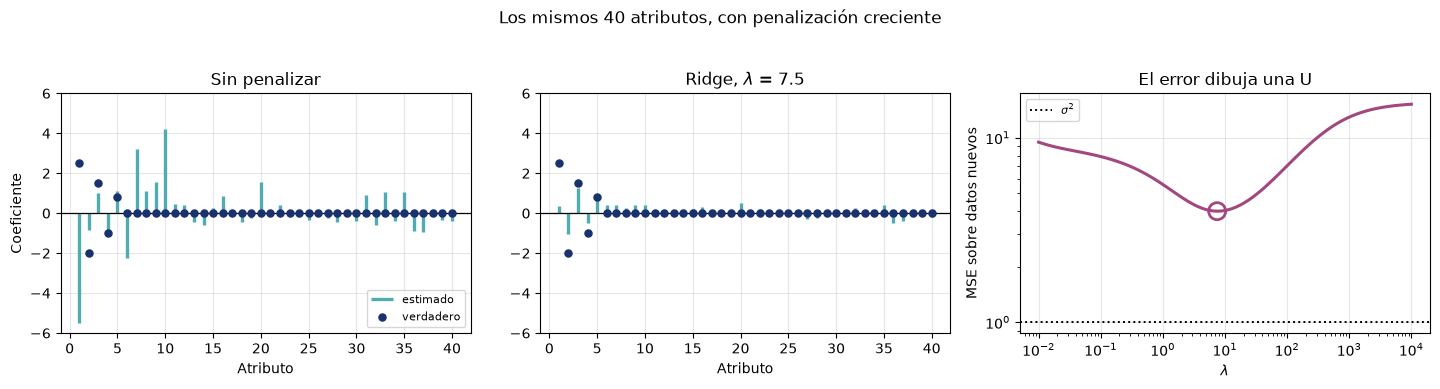

lambda que minimiza el error sobre datos nuevos: 7.48
MSE: 3.9956   contra 14.6026 sin penalizar (72.6 % mejor)


In [20]:
LAMBDAS_VISTA = [0.0, 1.0, 8.0, 30.0, 300.0]

print(f"{'lambda':>9} {'MSE datos nuevos':>18} {'||beta||':>12} {'mayor |b_j|':>13}")
for lam in LAMBDAS_VISTA:
    beta, b0 = ridge_desde_cero(X_tab, y_tab, lam)
    mse_l = mean_squared_error(y_tab_nv, X_tab_nv @ beta + b0)
    print(f"{lam:>9g} {mse_l:>18.4f} {np.linalg.norm(beta):>12.4f} {np.abs(beta).max():>13.4f}")
print(f"\nsigma^2 = {SIGMA_TAB ** 2:.2f}: ningún modelo puede bajar de ahí.")

# El barrido fino, para la U
grilla_lam = np.geomspace(1e-2, 1e4, 120)
mse_ridge = np.array([mean_squared_error(
    y_tab_nv, X_tab_nv @ ridge_desde_cero(X_tab, y_tab, l)[0] + ridge_desde_cero(X_tab, y_tab, l)[1])
    for l in grilla_lam])
lam_opt = grilla_lam[int(np.argmin(mse_ridge))]

indices = np.arange(1, P_TOTAL + 1)
beta_ridge_opt, _ = ridge_desde_cero(X_tab, y_tab, lam_opt)

fig, ejes = plt.subplots(1, 3, figsize=(14.5, 3.7))
for eje, coef, rotulo in [(ejes[0], sin_penalizar.coef_, "Sin penalizar"),
                          (ejes[1], beta_ridge_opt, f"Ridge, $\\lambda$ = {lam_opt:.1f}")]:
    eje.vlines(indices, 0, coef, color=TURQUESA, lw=2.4, label="estimado")
    eje.scatter(indices, BETA_VERDADERO, color=AZUL, s=26, zorder=3, label="verdadero")
    eje.axhline(0, color="black", lw=0.9)
    eje.set_ylim(-6, 6)
    eje.set_xlabel("Atributo")
    eje.set_title(rotulo)
ejes[0].set_ylabel("Coeficiente")
ejes[0].legend(fontsize=8, loc="lower right")

ejes[2].plot(grilla_lam, mse_ridge, lw=2.2, color=VIOLETA)
ejes[2].axhline(SIGMA_TAB ** 2, color="black", ls=":", lw=1.4, label=r"$\sigma^2$")
ejes[2].scatter([lam_opt], [mse_ridge.min()], s=150, facecolor="none",
                edgecolor=VIOLETA, lw=2, zorder=5)
ejes[2].set_xscale("log")
ejes[2].set_yscale("log")
ejes[2].set_xlabel(r"$\lambda$")
ejes[2].set_ylabel("MSE sobre datos nuevos")
ejes[2].set_title("El error dibuja una U")
ejes[2].legend(fontsize=8)
fig.suptitle("Los mismos 40 atributos, con penalización creciente", y=1.04)
fig.tight_layout()
plt.show()

print(f"lambda que minimiza el error sobre datos nuevos: {lam_opt:.2f}")
print(f"MSE: {mse_ridge.min():.4f}   contra {mse_nuevos:.4f} sin penalizar "
      f"({100 * (1 - mse_ridge.min() / mse_nuevos):.1f} % mejor)")

### Para analizar

1. Los 40 atributos están disponibles en los dos primeros paneles: **son el mismo modelo, con los
   mismos coeficientes libres**. Decir entonces qué es lo que cambia entre uno y otro, y por qué
   el segundo se parece más al coeficiente verdadero teniendo exactamente la misma libertad.
2. Al pasar de $\lambda=8$ a $\lambda=300$ el error **vuelve a subir**. Nombrar cuál de los dos
   términos de la descomposición está creciendo ahí, y cuál se siguió reduciendo. Mirar la
   columna $\lVert\beta\rVert$ de la tabla antes de responder.
3. La tabla del número de condición y la de los MSE cuentan la misma historia con dos
   vocabularios distintos. Enunciar la correspondencia en una oración.
4. En el panel de Ridge, los 35 coeficientes que valen cero de verdad **quedaron chicos pero no
   nulos**. ¿Podría alguno haber dado cero exacto? Justificar mirando la forma cerrada.

**Respuesta:**

1. No cambia la familia lineal ni la cantidad de coeficientes disponibles; cambia el criterio de ajuste. Ridge acepta algo más de residuo de entrenamiento a cambio de una norma $\lVert\beta\rVert_2$ menor. Eso impide que el ruido y la colinealidad produzcan coeficientes enormes, y por eso la estimación queda más cerca del vector verdadero.
2. Con penalización excesiva crece el sesgo: los coeficientes relevantes también se encogen hacia cero. La varianza continúa bajando, como sugiere la caída de $\lVert\beta\rVert$ de $2{,}3275$ a $0{,}6160$, pero ya no compensa el sesgo agregado.
3. Al crecer $\lambda$, el número de condición cae y el sistema amplifica menos las pequeñas variaciones de la muestra; estadísticamente, eso es menor varianza y mejor error fuera de muestra hasta que el sesgo pasa a dominar.
4. No de manera sistemática para un $\lambda$ finito. La solución de Ridge es una transformación lineal suave y no contiene un umbral que fuerce coordenadas a cero; un cero exacto sólo aparecería por una cancelación algebraica particular (por ejemplo, si la componente correspondiente ya fuera exactamente cero), no por el mecanismo de Ridge.

---

# 4. La otra penalización: el caso ortonormal

Ridge encoge todos los coeficientes pero **no anula ninguno**: la solución cerrada es un producto de matrices y no hay razón para que una coordenada dé exactamente cero. El modelo penalizado sigue teniendo sus 40 atributos, incluidos los 35 que no influyen en nada.

El Lasso cambia la norma de la penalización y con eso cambia cualitativamente el resultado:

$$
J^{L}(\boldsymbol{\beta})
\;=\;
\lVert\mathbf{y}-\mathbf{X}\boldsymbol{\beta}\rVert^2
\;+\;
\lambda\lVert\boldsymbol{\beta}\rVert_1 ,
\qquad
\lVert\boldsymbol{\beta}\rVert_1 = \sum_{j=1}^{p}\lvert\beta_j\rvert .
$$

**En el caso general no tiene forma cerrada**: el problema es convexo, pero $\lvert\beta_j\rvert$ no es diferenciable en cero, de modo que no se puede igualar el gradiente a cero y despejar. Se resuelve con subgradiente o descenso por coordenadas, que la clase nombró y dejó fuera de su alcance. **Acá se usa la implementación de la biblioteca para el caso general.**

**Pero hay un caso donde sí hay forma cerrada, y es el que la clase derivó**: cuando las columnas son ortonormales, $\mathbf{X}^\top\mathbf{X}=\mathbf{I}$, el problema se separa en $p$ problemas de una variable y cada uno se resuelve mirando el signo. El resultado es el par de fórmulas que distingue a las dos penalizaciones:

$$
\hat\beta^{R}_j \;=\; \frac{\hat\beta_j}{1+\lambda}
\qquad\text{(encogimiento proporcional)},
$$

$$
\hat\beta^{L}_j \;=\; \operatorname{sign}(\hat\beta_j)\,
\max\Bigl(\lvert\hat\beta_j\rvert-\frac{\lambda}{2},\;0\Bigr)
\qquad\text{(umbral suave)},
$$

donde $\hat\beta_j$ son los coeficientes de mínimos cuadrados. **Ahí se ve el cero exacto sin necesidad de ninguna figura**: Ridge multiplica por un factor menor que uno, que nunca llega a cero; el Lasso resta una cantidad fija y **se detiene en cero** cuando no alcanza.

### Ejercicio 4: el umbral suave

Corresponde escribir la función $S$. Es **una línea**, y sale directamente de la fórmula de arriba.

$$
S(z,\gamma) \;=\; \operatorname{sign}(z)\,\max\bigl(\lvert z\rvert-\gamma,\;0\bigr)
$$

Conviene escribirla con `np.sign` y `np.maximum` para que funcione tanto sobre un
número como sobre un array completo.

In [21]:
def soft_umbral(z: np.ndarray | float, gamma: float) -> np.ndarray | float:
    """Umbral suave: acerca z a cero en gamma, y lo deja en cero si no alcanza."""
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0)

In [22]:
# VERIFICACIÓN — cuatro casos que se leen a ojo
assert np.isclose(soft_umbral(5.0, 2.0), 3.0)        # positivo: sobrevive, encogido en 2
assert np.isclose(soft_umbral(-5.0, 2.0), -3.0)      # negativo: simétrico
assert np.isclose(soft_umbral(1.0, 2.0), 0.0)        # no alcanza: CERO EXACTO
assert np.isclose(soft_umbral(-1.0, 2.0), 0.0)
assert np.allclose(soft_umbral(np.array([5.0, 1.0, -5.0]), 2.0), [3.0, 0.0, -3.0])
print("soft_umbral: correcto, sobre escalares y sobre arrays.")

soft_umbral: correcto, sobre escalares y sobre arrays.


### Las dos fórmulas, verificadas contra la biblioteca

La celda siguiente reproduce el experimento de la exposición: se construye una matriz con columnas **exactamente ortonormales** (las de una descomposición QR), se ajusta por mínimos cuadrados, y se comparan las dos fórmulas cerradas contra lo que devuelven `Ridge` y `Lasso`.

Es donde la caja de traducción de la sección 3 se vuelve indispensable: **`Lasso` de `scikit-learn` lleva un $1/(2n)$ en el término de ajuste**, de modo que reproducir un $\lambda$ del curso exige pasarle `alpha = lam / (2 * n)`. Con `alpha = lam` las cifras no coincidirían y no habría forma de saber si el error está en la fórmula o en la traducción.

In [23]:
n_orto = 200
LAM_ORTO = 1.0

r_orto = np.random.default_rng(SEMILLA)
Q, _ = np.linalg.qr(r_orto.normal(size=(n_orto, 5)))      # X^T X = I exactamente
beta_orto = np.array([4.0, 2.0, 0.5, -3.0, 0.05])
y_orto = Q @ beta_orto + r_orto.normal(0, 0.05, n_orto)

print(f"máx |X^T X - I| = {np.abs(Q.T @ Q - np.eye(5)).max():.2e}   (ortonormal), n = {n_orto}")
print(f"lambda = {LAM_ORTO}  ->  Ridge alpha = {LAM_ORTO},  "
      f"Lasso alpha = lambda/(2n) = {LAM_ORTO / (2 * n_orto):.6f}")

beta_ols = Q.T @ y_orto                                   # con X^T X = I, OLS es X^T y
beta_ridge_bib = Ridge(alpha=LAM_ORTO, fit_intercept=False).fit(Q, y_orto).coef_
beta_lasso_bib = Lasso(alpha=LAM_ORTO / (2 * n_orto), fit_intercept=False,
                       max_iter=500_000, tol=1e-14).fit(Q, y_orto).coef_

proporcional = beta_ols / (1 + LAM_ORTO)                  # la fórmula de Ridge
umbral = soft_umbral(beta_ols, LAM_ORTO / 2)              # la fórmula del Lasso

print(f"\n{'j':>3} {'OLS':>10} {'Ridge bib.':>12} {'b/(1+lam)':>12} "
      f"{'Lasso bib.':>12} {'soft(lam/2)':>13}")
for j in range(5):
    print(f"{j + 1:>3} {beta_ols[j]:>10.4f} {beta_ridge_bib[j]:>12.4f} "
          f"{proporcional[j]:>12.4f} {beta_lasso_bib[j]:>12.4f} {umbral[j]:>13.4f}")

print(f"\nmáx |Ridge - b/(1+lambda)|   = {np.abs(beta_ridge_bib - proporcional).max():.3e}")
print(f"máx |Lasso - soft(lambda/2)| = {np.abs(beta_lasso_bib - umbral).max():.3e}")
assert np.allclose(beta_ridge_bib, proporcional)
assert np.allclose(beta_lasso_bib, umbral, atol=1e-8)

nulos = int((beta_lasso_bib == 0).sum())
print(f"\ncoeficientes exactamente nulos en el Lasso: {nulos} de 5")
print(f"son los de |OLS| <= lambda/2 = {LAM_ORTO / 2}")

máx |X^T X - I| = 6.66e-16   (ortonormal), n = 200
lambda = 1.0  ->  Ridge alpha = 1.0,  Lasso alpha = lambda/(2n) = 0.002500

  j        OLS   Ridge bib.    b/(1+lam)   Lasso bib.   soft(lam/2)
  1     3.9624       1.9812       1.9812       3.4624        3.4624
  2     1.9192       0.9596       0.9596       1.4192        1.4192
  3     0.5218       0.2609       0.2609       0.0218        0.0218
  4    -3.0335      -1.5167      -1.5167      -2.5335       -2.5335
  5     0.0045       0.0023       0.0023       0.0000        0.0000

máx |Ridge - b/(1+lambda)|   = 4.441e-16
máx |Lasso - soft(lambda/2)| = 4.441e-16

coeficientes exactamente nulos en el Lasso: 1 de 5
son los de |OLS| <= lambda/2 = 0.5


### El camino de regularización, sobre los 40 atributos

Vuelta al conjunto de 45 observaciones. La trayectoria de cada coeficiente en función de
$\lambda$, para las dos penalizaciones, y el panel que las separa: **cuántos atributos
sobreviven**.

Ridge sale de la implementación propia; el Lasso, de la biblioteca, con la traducción
$\alpha=\lambda/(2n)$. **Las dos comparten la grilla de $\lambda$**, que es la del curso.

Y acá aparece algo que con datos reales no se puede hacer: como el $\boldsymbol\beta$ verdadero se conoce, no sólo se puede contar cuántos atributos elige el Lasso, sino **cuáles**: cuántos de los 5 que importan recupera, y cuántos de los 35 que no importan se le cuelan.

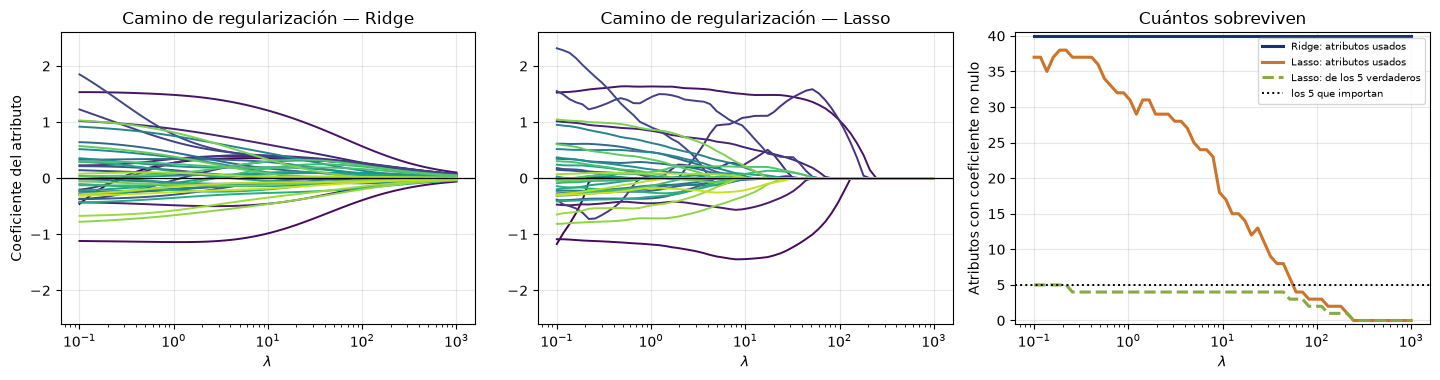

  lambda   MSE Ridge   MSE Lasso  elegidos  de los 5  del bloque   otros
       1      5.5749      5.2858        32         4           2      26
       5      4.0737      2.6110        25         4           3      18
      11      4.0575      2.0607        17         4           3      10
      30      4.8453      2.8598        11         4           4       3
     100      7.0376      7.8619         3         2           1       0

sin penalizar: MSE 14.60   ·   cota irreducible: sigma^2 = 1.00
('del bloque' son los atributos 6 a 10, las casi copias del atributo 1)


In [24]:
def lasso_biblioteca(X: np.ndarray, y: np.ndarray, lam: float) -> tuple[np.ndarray, float]:
    """Lasso con la convención de lambda del curso, delegando en scikit-learn."""
    modelo = Lasso(alpha=lam / (2 * len(y)), max_iter=200_000).fit(X, y)
    return modelo.coef_, float(modelo.intercept_)


grilla = np.geomspace(1e-1, 1e3, 60)
camino_ridge = np.array([ridge_desde_cero(X_tab, y_tab, l)[0] for l in grilla])
camino_lasso = np.array([lasso_biblioteca(X_tab, y_tab, l)[0] for l in grilla])

fig, ejes = plt.subplots(1, 3, figsize=(14.5, 3.9))
colores = plt.cm.viridis(np.linspace(0, 0.92, P_TOTAL))

for eje, camino, rotulo in [(ejes[0], camino_ridge, "Ridge"),
                            (ejes[1], camino_lasso, "Lasso")]:
    for j in range(P_TOTAL):
        eje.plot(grilla, camino[:, j], color=colores[j], lw=1.4)
    eje.set_xscale("log")
    eje.axhline(0, color="black", lw=0.9)
    eje.set_xlabel(r"$\lambda$")
    eje.set_ylim(-2.6, 2.6)
    eje.set_title(f"Camino de regularización — {rotulo}")
ejes[0].set_ylabel("Coeficiente del atributo")

no_nulos_r = (np.abs(camino_ridge) > 1e-8).sum(axis=1)
no_nulos_l = (np.abs(camino_lasso) > 1e-8).sum(axis=1)
verdaderos_l = (np.abs(camino_lasso[:, :P_RELEVANTES]) > 1e-8).sum(axis=1)

ejes[2].plot(grilla, no_nulos_r, lw=2.2, color=AZUL, label="Ridge: atributos usados")
ejes[2].plot(grilla, no_nulos_l, lw=2.2, color=NARANJA, label="Lasso: atributos usados")
ejes[2].plot(grilla, verdaderos_l, lw=2.2, color=OLIVA, ls="--",
             label="Lasso: de los 5 verdaderos")
ejes[2].axhline(P_RELEVANTES, color="black", ls=":", lw=1.4, label="los 5 que importan")
ejes[2].set_xscale("log")
ejes[2].set_ylim(-0.5, P_TOTAL + 0.5)
ejes[2].set_xlabel(r"$\lambda$")
ejes[2].set_ylabel("Atributos con coeficiente no nulo")
ejes[2].set_title("Cuántos sobreviven")
ejes[2].legend(fontsize=7.5)
fig.tight_layout()
plt.show()

print(f"{'lambda':>8} {'MSE Ridge':>11} {'MSE Lasso':>11} {'elegidos':>9} "
      f"{'de los 5':>9} {'del bloque':>11} {'otros':>7}")
for lam in [1.0, 5.0, 11.0, 30.0, 100.0]:
    br, b0r = ridge_desde_cero(X_tab, y_tab, lam)
    bl, b0l = lasso_biblioteca(X_tab, y_tab, lam)
    vivo = np.abs(bl) > 1e-8
    print(f"{lam:>8g} {mean_squared_error(y_tab_nv, X_tab_nv @ br + b0r):>11.4f} "
          f"{mean_squared_error(y_tab_nv, X_tab_nv @ bl + b0l):>11.4f} "
          f"{vivo.sum():>9} {vivo[:5].sum():>9} {vivo[5:10].sum():>11} {vivo[10:].sum():>7}")

print(f"\nsin penalizar: MSE {mse_nuevos:.2f}   ·   cota irreducible: sigma^2 = {SIGMA_TAB ** 2:.2f}")
print("('del bloque' son los atributos 6 a 10, las casi copias del atributo 1)")

### Para analizar

1. En el panel de la derecha, la curva de Ridge es **una recta horizontal en 40** y la del Lasso baja en escalones. Explicarlo con las dos fórmulas del caso ortonormal: qué le hace cada una a un coeficiente chico. **¿Qué tendría que pasar para que un coeficiente de Ridge diera cero exacto?**
2. En la tabla, los falsos positivos del Lasso no son cualquiera: mirar la columna **del bloque**, que cuenta los atributos 6 a 10 (las casi copias del atributo 1, todos con coeficiente verdadero cero) y decir por qué son justamente esos los que sobreviven. Relacionarlo con lo que la clase dijo sobre el Lasso y los atributos correlacionados.
3. Con la mejor penalización de cada una, el Lasso llega a un MSE bastante menor que Ridge. **¿Se puede concluir de acá que el Lasso es mejor que Ridge?** Decir qué propiedad de *este* problema lo favorece, y describir un problema donde la conclusión se daría vuelta.

**Respuesta:**

1. Ridge multiplica cada coeficiente por $1/(1+\lambda)$: para $\lambda$ finito conserva los 40 como no nulos, salvo que el coeficiente sin penalizar ya sea exactamente cero. Lasso resta $\lambda/2$ a su magnitud y fija en cero los que no superan ese umbral, de ahí la caída en escalones. En Ridge también se llega a cero sólo en el límite $\lambda\to\infty$.
2. Esos atributos son casi copias del atributo 1, por lo que pueden explicar prácticamente la misma parte de $y$. Ante predictores correlacionados, Lasso suele escoger uno o algunos representantes de manera inestable y no puede distinguir con seguridad cuál es el causal; por eso varios falsos positivos se concentran justamente en el bloque redundante.
3. No. Este proceso favorece al Lasso porque la verdad es muy dispersa: sólo 5 de 40 coeficientes son no nulos, y anular variables de ruido reduce mucho la varianza. En un problema denso, con muchos efectos pequeños repartidos entre predictores correlacionados, Ridge puede ser mejor porque conserva y reparte la señal en lugar de descartarla.

---

# 5. La misma medición, ahora sobre $\lambda$

Hasta acá las dos mitades corrieron por separado. La sección 1 **midió** sesgo y varianza moviendo la complejidad; las secciones 3 y 4 **mostraron** qué le hace la penalización a un ajuste concreto, pero sobre un único conjunto de 45 observaciones, donde no hay varianza que medir porque no hay más que una muestra.

Falta unirlas, y la forma de hacerlo es repetir el experimento de la sección 1 con una sola diferencia: **la perilla ya no es la complejidad del modelo, es $\lambda$**.

El experimento fija los 40 atributos y ajusta, sobre cada uno de los $B=500$ conjuntos de 45 observaciones, un modelo penalizado. Si la penalización hace lo que la clase afirma, se tienen que observar tres cosas:

- el **sesgo al cuadrado crece** con $\lambda$, porque la penalización aleja al modelo del mejor ajuste posible dentro de la familia;
- la **varianza cae**, porque los coeficientes ya no pueden dispararse cuando el conjunto cambia;
- la **suma tiene un mínimo en algún $\lambda > 0$**, y no en el extremo.

Esa tercera es la que importa: **si el mínimo estuviera en $\lambda=0$, regularizar no serviría nunca.**

### Ejercicio 5: la simulación penalizada

Corresponde escribir una función que sirva para las dos penalizaciones. Recibe **la función de ajuste** como argumento (`ridge_desde_cero` o `lasso_biblioteca`, que tienen la misma firma y devuelven lo mismo) y hace el resto. Son **cinco líneas**.

**Pseudocódigo.**

```
crear una matriz P vacía, de forma (B, cantidad de puntos de prueba)
para b desde 0 hasta B-1:
    sortear un conjunto (X, y) de n observaciones con generar_atributos
    ajustar con la función recibida, con la penalización lam
    predecir en los puntos de prueba:  X_prueba @ beta + intercepto
    guardar en la fila b de P
devolver P
```

**La única diferencia con `simular` de la sección 1** es que el ajuste ya no es el modelo sin penalizar sino la función que se recibe por parámetro, y que la predicción es el producto matricial explícito en lugar de llamar a un objeto ajustado.

**Se reutiliza `descomponer` sin tocarla.** Recibe una matriz de predicciones y no le importa de dónde salió: es la señal de que la medición es la misma y sólo cambió el modelo.

In [25]:
N_TAB = 45          # observaciones por conjunto de entrenamiento
N_PRUEBA = 200      # puntos de prueba, FIJOS

r_prueba = np.random.default_rng(7)
X_prueba, _ = generar_atributos(N_PRUEBA, r_prueba)
f_prueba = X_prueba @ BETA_VERDADERO     # la verdad en esos puntos: acá se conoce

print(f"puntos de prueba: {X_prueba.shape[0]} filas x {X_prueba.shape[1]} atributos")
print(f"cada conjunto de entrenamiento tiene {N_TAB} observaciones: "
      f"n/p = {N_TAB / P_TOTAL:.2f}")

puntos de prueba: 200 filas x 40 atributos
cada conjunto de entrenamiento tiene 45 observaciones: n/p = 1.12


In [26]:
def simular_penalizado(ajuste, lam: float, rng: np.random.Generator,
                       B: int = B, n: int = N_TAB) -> np.ndarray:
    """Ajusta B modelos penalizados, cada uno sobre su propio conjunto sorteado.

    Parámetros
    ----------
    ajuste : función de ajuste con la firma (X, y, lam) -> (beta, intercepto).
             Se le pasa `ridge_desde_cero` o `lasso_biblioteca`
    lam    : lambda de la penalización, en la convención del curso
    rng    : generador
    B      : cantidad de conjuntos de entrenamiento
    n      : observaciones por conjunto

    Devuelve
    --------
    (B, N_PRUEBA) : la fila b son las predicciones del modelo b en los puntos de prueba
    """
    predicciones = np.empty((B, N_PRUEBA))
    for b in range(B):
        X, y = generar_atributos(n, rng)
        beta, intercepto = ajuste(X, y, lam)
        predicciones[b] = X_prueba @ beta + intercepto
    return predicciones

In [27]:
# VERIFICACIÓN — con lambda = 0, Ridge tiene que dar el ajuste sin penalizar
rc = np.random.default_rng(SEMILLA)
P_ridge0 = simular_penalizado(ridge_desde_cero, 0.0, rc, B=20)

rc = np.random.default_rng(SEMILLA)
P_directo = np.empty((20, N_PRUEBA))
for b in range(20):
    Xb, yb = generar_atributos(N_TAB, rc)
    modelo_b = LinearRegression().fit(Xb, yb)
    P_directo[b] = modelo_b.predict(X_prueba)

assert P_ridge0.shape == (20, N_PRUEBA), f"forma inesperada: {P_ridge0.shape}"
print(f"diferencia máxima contra el ajuste sin penalizar: "
      f"{np.max(np.abs(P_ridge0 - P_directo)):.3e}")
assert np.allclose(P_ridge0, P_directo, atol=1e-6)
print("Los dos caminos de ajuste son el mismo modelo. La única diferencia va a ser lambda.")

diferencia máxima contra el ajuste sin penalizar: 5.064e-11
Los dos caminos de ajuste son el mismo modelo. La única diferencia va a ser lambda.


In [28]:
lambdas_ridge = np.array([0.0, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0, 1000.0])
rr = np.random.default_rng(SEMILLA)
filas_ridge = []

print(f"RIDGE   {'lambda':>10} {'Sesgo^2':>10} {'Varianza':>12} {'suma de los tres':>18}")
for lam in lambdas_ridge:
    Pl = simular_penalizado(ridge_desde_cero, lam, rr)
    s2_l, var_l = descomponer(Pl, f_prueba)
    filas_ridge.append((s2_l, var_l, s2_l + var_l + SIGMA_TAB ** 2))
    print(f"{'':>8}{lam:>10.4g} {s2_l:>10.4f} {var_l:>12.4f} {filas_ridge[-1][2]:>18.4f}")

filas_ridge = np.array(filas_ridge)
mejor_r = lambdas_ridge[int(np.argmin(filas_ridge[:, 2]))]
print(f"\nlambda que minimiza la suma: {mejor_r:g}   suma: {filas_ridge[:, 2].min():.4f}")
print(f"contra {filas_ridge[0, 2]:.4f} sin penalizar: "
      f"mejora del {100 * (1 - filas_ridge[:, 2].min() / filas_ridge[0, 2]):.1f} %")

RIDGE       lambda    Sesgo^2     Varianza   suma de los tres
                 0     0.0179      13.3618            14.3798
               0.1     0.0168       4.4646             5.4813
                 1     0.0641       2.2318             3.2959
                 3     0.2391       1.6118             2.8509
                10     0.8523       1.1504             3.0027
                30     2.0976       0.8738             3.9715
               100     4.4851       0.5580             6.0431
              1000     9.9429       0.2773            11.2201

lambda que minimiza la suma: 3   suma: 2.8509
contra 14.3798 sin penalizar: mejora del 80.2 %


In [29]:
lambdas_lasso = np.array([0.1, 1.0, 3.0, 10.0, 30.0, 100.0])
rz = np.random.default_rng(SEMILLA)
filas_lasso = []

print(f"LASSO   {'lambda':>10} {'Sesgo^2':>10} {'Varianza':>12} {'suma de los tres':>18}")
for lam in lambdas_lasso:
    Pl = simular_penalizado(lasso_biblioteca, lam, rz)
    s2_l, var_l = descomponer(Pl, f_prueba)
    filas_lasso.append((s2_l, var_l, s2_l + var_l + SIGMA_TAB ** 2))
    print(f"{'':>8}{lam:>10.4g} {s2_l:>10.4f} {var_l:>12.4f} {filas_lasso[-1][2]:>18.4f}")

filas_lasso = np.array(filas_lasso)
mejor_l = lambdas_lasso[int(np.argmin(filas_lasso[:, 2]))]
print(f"\nlambda que minimiza la suma: {mejor_l:g}   suma: {filas_lasso[:, 2].min():.4f}")
print(f"\nLas dos penalizaciones tienen su mínimo en un lambda estrictamente positivo.")

LASSO       lambda    Sesgo^2     Varianza   suma de los tres
               0.1     0.0115       6.1809             7.1924
                 1     0.0208       1.9707             2.9915
                 3     0.0487       0.9433             1.9919
                10     0.1728       0.4213             1.5941
                30     0.9221       0.3821             2.3042
               100     5.3400       0.6285             6.9685

lambda que minimiza la suma: 10   suma: 1.5941

Las dos penalizaciones tienen su mínimo en un lambda estrictamente positivo.


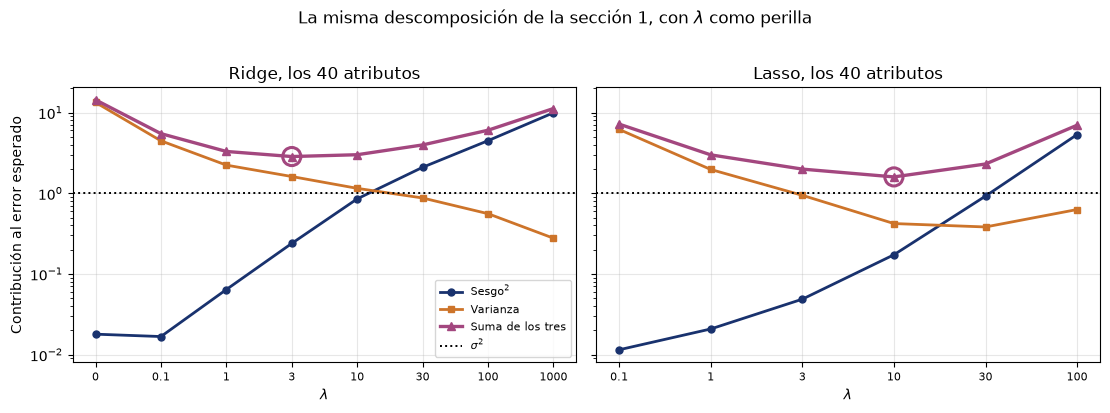

In [30]:
fig, ejes = plt.subplots(1, 2, figsize=(11.2, 4.0), sharey=True)

for eje, lams, filas, rotulo in [(ejes[0], lambdas_ridge, filas_ridge, "Ridge"),
                                 (ejes[1], lambdas_lasso, filas_lasso, "Lasso")]:
    posicion = np.arange(len(lams))
    eje.plot(posicion, filas[:, 0], "o-", color=AZUL, lw=2, ms=5, label="Sesgo$^2$")
    eje.plot(posicion, filas[:, 1], "s-", color=NARANJA, lw=2, ms=5, label="Varianza")
    eje.plot(posicion, filas[:, 2], "^-", color=VIOLETA, lw=2.4, ms=6,
             label="Suma de los tres")
    eje.axhline(SIGMA_TAB ** 2, color="black", ls=":", lw=1.4, label=r"$\sigma^2$")
    j_min = int(np.argmin(filas[:, 2]))
    eje.scatter([posicion[j_min]], [filas[j_min, 2]], s=170, facecolor="none",
                edgecolor=VIOLETA, lw=2.2, zorder=5)
    eje.set_xticks(posicion)
    eje.set_xticklabels([f"{l:g}" for l in lams], fontsize=8)
    eje.set_yscale("log")
    eje.set_xlabel(r"$\lambda$")
    eje.set_title(f"{rotulo}, los 40 atributos")
ejes[0].set_ylabel("Contribución al error esperado")
ejes[0].legend(fontsize=8)
fig.suptitle(r"La misma descomposición de la sección 1, con $\lambda$ como perilla", y=1.02)
fig.tight_layout()
plt.show()

### Para analizar

1. Comparar estas dos figuras con la de la sección 1. **¿Qué cambió y qué se mantiene?** En
   particular: cuál es la perilla en cada caso, y qué diferencia práctica hay entre moverlas.
2. El extremo izquierdo del panel de Ridge, $\lambda=0$, es **el mismo modelo sin penalizar** que
   la sección 3 ajustó sobre un único conjunto. Ahí su varianza es enorme. Explicar, sin hacer
   ninguna cuenta nueva, por qué esa varianza tiene que ser grande a partir del cociente $n/p$.
3. En las dos penalizaciones la suma tiene su mínimo en un $\lambda$ **estrictamente positivo**.
   Expresar en una oración, en términos de los dos términos de la descomposición, **qué se compró
   y qué se pagó**.
4. El mejor Lasso queda por debajo del mejor Ridge. Con lo medido en la sección 4 sobre qué
   atributos sobreviven, **explicar por qué**: qué tiene este proceso que le da ventaja a una de
   las dos penalizaciones.

**Respuesta:**

1. En la sección 1 la perilla es el grado: cambiarlo agrega o quita términos y, por tanto, cambia discretamente la familia. Aquí la familia mantiene los 40 atributos y la perilla continua es $\lambda$, que cambia cuánto se permiten coeficientes grandes (y, en Lasso, cuáles quedan en cero). Se mantiene el mismo compromiso: al restringir, sube el sesgo, baja la varianza y la suma dibuja una U.
2. Con $n/p=45/40=1{,}125$ apenas hay más observaciones que coeficientes. El ajuste está casi saturado y, además, contiene un bloque muy colineal, de modo que pequeñas variaciones entre muestras producen grandes cambios en los coeficientes y una varianza enorme.
3. Se compró una reducción de varianza mayor que el aumento de sesgo que se pagó; por eso el error total alcanza su mínimo con $\lambda>0$.
4. La verdad tiene sólo 5 señales entre 40 atributos. Lasso puede anular gran parte de los 35 atributos irrelevantes y alcanza una suma mínima de $1{,}5941$, mientras Ridge conserva los 40 y su mínimo es $2{,}8509$; la dispersión real del proceso le da ventaja al Lasso.

---

# 6. ¿Y en datos reales?

Todo lo anterior corrió sobre una simulación, que es lo único que permite verificar la identidad.
Queda la pregunta que decide si algo de esto se usa: **¿penalizar mejora siempre?**

La respuesta se deduce de lo que ya se midió. Penalizar **agrega sesgo** y **compra varianza**.
Si el modelo casi no tenía varianza que comprar, se paga el sesgo y no se recibe nada. La
sección 1 mostró que la varianza depende de cuántos coeficientes hay que estimar con cuántas
observaciones: la cantidad relevante es $n/p$.

El experimento contrasta dos regímenes opuestos sobre el **mismo** conjunto de datos reales (precios de viviendas, ocho atributos, tres de ellos redundantes entre sí porque la superficie habitable es aproximadamente la suma de las dos plantas) cambiando una sola cosa: cuántas filas se usan para entrenar.

| Escenario | $n$ | $p$ | $n/p$ | Qué se espera |
|---|---|---|---|---|
| 1 | 1022 | 8 | $\approx 128$ | Sobra información por coeficiente: poca varianza que comprar |
| 2 | 40 | 8 | $5$ | Cada coeficiente estimado con muy poca información |

> El tercer régimen posible (**ampliar la familia** en vez de recortar la muestra) es el de las secciones 3 a 5: cuarenta atributos para cuarenta y cinco observaciones es exactamente eso, y produjo el mismo efecto que sacar filas. Los dos caminos llegan al mismo lugar porque lo que importa no es $n$ ni $p$ por separado, sino su cociente.

Todo lo que sigue viene resuelto. El trabajo es **leer las cifras y decidir**.

### Los datos

La partición se hace **antes** de cualquier cálculo, y el escalador se ajusta sobre el conjunto de entrenamiento y se aplica al de prueba. Estandarizar no es opcional acá, a diferencia de los tributos simulados de la sección 3, que ya venían en la misma escala: la penalización suma $\beta_j^2$, de modo que un atributo medido en pies cuadrados y otro medido en años quedan penalizados con dureza muy distinta sin que eso tenga nada que ver con su importancia.

In [31]:
from pathlib import Path

ATRIBUTOS = ["GrLivArea", "TotalBsmtSF", "GarageArea", "GarageCars",
             "YearBuilt", "OverallQual", "1stFlrSF", "2ndFlrSF"]
RESPUESTA = "SalePrice"

rutas = [Path("data/ames_reducido.csv"),
         Path("../../data/ames_reducido.csv"),
         Path("ames_reducido.csv")]
archivo = next((r for r in rutas if r.exists()), None)

if archivo is None:                      # En Colab: subir el archivo a mano
    from google.colab import files       # type: ignore
    subidos = files.upload()
    archivo = Path(next(iter(subidos)))

viviendas = pd.read_csv(archivo)
X_todo = viviendas[ATRIBUTOS].to_numpy(dtype=float)
y_todo = viviendas[RESPUESTA].to_numpy(dtype=float)

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X_todo, y_todo, test_size=0.30, random_state=SEMILLA)

escalador = StandardScaler().fit(X_ent)
Z_ent, Z_pru = escalador.transform(X_ent), escalador.transform(X_pru)

print(f"Cargado: {archivo}   {viviendas.shape[0]} viviendas")
print(f"entrenamiento: {Z_ent.shape}    prueba: {Z_pru.shape}")

Cargado: data/ames_reducido.csv   1460 viviendas
entrenamiento: (1022, 8)    prueba: (438, 8)


### La comparación

En cada escenario se ajustan tres modelos sin penalizar, Ridge y Lasso y se los evalúa sobre **el mismo conjunto de prueba**, que no participa de ninguna decisión. El $\lambda$ de cada penalización se elige por validación cruzada de 10 particiones **dentro del conjunto de entrenamiento**: elegirlo mirando el conjunto de prueba sería usar dos veces los mismos datos y la comparación dejaría de significar algo.

Acá se usan `RidgeCV` y `LassoCV` de la biblioteca, no las implementaciones propias: lo que se está midiendo ya no es el algoritmo sino la decisión metodológica.

In [32]:
def comparar(Z_a: np.ndarray, y_a: np.ndarray, Z_p: np.ndarray, y_p: np.ndarray,
             etiqueta: str) -> None:
    """Ajusta los tres modelos y reporta el RMSE sobre el conjunto de prueba."""
    folds = KFold(n_splits=min(10, len(y_a)), shuffle=True, random_state=SEMILLA)
    grilla_cv = np.geomspace(1e-2, 1e7, 200)

    ols = LinearRegression().fit(Z_a, y_a)
    ridge = RidgeCV(alphas=grilla_cv, cv=folds).fit(Z_a, y_a)
    lasso = LassoCV(alphas=grilla_cv, cv=folds, max_iter=200_000,
                    random_state=SEMILLA).fit(Z_a, y_a)

    base = np.sqrt(mean_squared_error(y_p, ols.predict(Z_p)))
    print(f"\n{etiqueta}   n = {Z_a.shape[0]}, p = {Z_a.shape[1]}, "
          f"n/p = {Z_a.shape[0] / Z_a.shape[1]:.1f}")
    print(f"  {'sin penalizar':<16} RMSE {base:>12,.0f}")
    for nombre, modelo in [("Ridge", ridge), ("Lasso", lasso)]:
        rmse = np.sqrt(mean_squared_error(y_p, modelo.predict(Z_p)))
        mejora = 100 * (base - rmse) / base
        extra = ""
        if nombre == "Lasso":
            extra = f", {int((np.abs(modelo.coef_) > 1e-8).sum())} de {Z_a.shape[1]} no nulos"
        print(f"  {nombre:<16} RMSE {rmse:>12,.0f}   "
              f"({mejora:+.1f} %, lambda* = {modelo.alpha_:,.1f}{extra})")


# Escenario 1 — el conjunto completo
comparar(Z_ent, y_ent, Z_pru, y_pru, "Escenario 1")

# Escenario 2 — los mismos ocho atributos, pero con solo 40 filas de entrenamiento
sub = np.random.default_rng(SEMILLA).choice(len(y_ent), 40, replace=False)
escalador_2 = StandardScaler().fit(X_ent[sub])
comparar(escalador_2.transform(X_ent[sub]), y_ent[sub],
         escalador_2.transform(X_pru), y_pru, "Escenario 2")

print("\n(Un porcentaje positivo es mejora sobre el modelo sin penalizar; uno negativo,")
print(" empeoramiento. Todos los RMSE están en dólares.)")


Escenario 1   n = 1022, p = 8, n/p = 127.8
  sin penalizar    RMSE       37,482
  Ridge            RMSE       38,037   (-1.5 %, lambda* = 178.3)
  Lasso            RMSE       37,842   (-1.0 %, lambda* = 1,162.3, 7 de 8 no nulos)

Escenario 2   n = 40, p = 8, n/p = 5.0
  sin penalizar    RMSE       37,962
  Ridge            RMSE       40,160   (-5.8 %, lambda* = 56.7)
  Lasso            RMSE       35,846   (+5.6 %, lambda* = 2,409.4, 5 de 8 no nulos)

(Un porcentaje positivo es mejora sobre el modelo sin penalizar; uno negativo,
 empeoramiento. Todos los RMSE están en dólares.)


### DECIDE

1. **¿En qué escenario conviene penalizar y en cuál no?** Nombrar la cifra concreta que lo decide en cada caso.
2. El escenario 1 tiene $n/p \approx 128$. Con la descomposición en la mano, **explicar por qué penalizar ahí no puede mejorar nada**: qué término se agrega, qué término se esperaba comprar a cambio, y por qué el intercambio sale mal.
3. **¿Alguna de las dos penalizaciones domina a la otra?** Señalar las cifras que responden la pregunta y enunciar el criterio que decide cuál usar en un problema nuevo. Tener en cuenta lo observado en la sección 4 sobre qué términos sobreviven.
4. El escenario 2 se construyó **sacando filas**, y las secciones 3 a 5 llegaron al mismo régimen **teniendo muchos atributos por observación**. Explicar por qué las dos operaciones producen el mismo efecto, y enunciar en una oración cuál es la condición verificable que dice si conviene penalizar.

**Respuesta:**

1. En el escenario 1 no conviene penalizar: OLS obtiene RMSE $37.482$, frente a $38.037$ de Ridge y $37.842$ de Lasso. En el escenario 2 sí conviene Lasso, que baja de $37.962$ a $35.846$ ($5{,}6\%$); Ridge no conviene allí porque sube a $40.160$.
2. Con $n/p=127{,}8$ los coeficientes se estiman con abundante información y hay poca varianza que reducir. La penalización agrega sesgo, pero la reducción de varianza es insuficiente para compensarlo; por eso ambos modelos penalizados empeoran el RMSE.
3. Ninguna domina: en el escenario 1 OLS gana a ambas y en el escenario 2 Lasso gana mientras Ridge pierde. Para un problema nuevo se deben comparar por validación cruzada, incluyendo $\lambda=0$ o el modelo sin penalizar. Si se espera una señal dispersa, la selección de variables de Lasso puede ayudar; si la señal es densa o está repartida entre variables correlacionadas, Ridge puede resultar preferible.
4. Sacar filas reduce la información disponible por coeficiente; agregar atributos aumenta la cantidad de coeficientes que compiten por la misma información. Ambas operaciones reducen $n/p$, vuelven inestable el ajuste y elevan su varianza. La condición verificable es que la reducción de error de validación debida a menor varianza supere el sesgo agregado por penalizar.

---

## Cierre

- **La descomposición se verificó, no se ilustró.** La suma de los tres términos y el error esperado estimado por un camino independiente coinciden en todas las filas de la tabla, y se calcularon con códigos que no comparten una línea.
- **El óptimo no está en ningún extremo.** Ni el modelo que minimiza el sesgo ni el que minimiza la varianza minimizan el error. Esa es toda la razón por la que existe la regularización.
- **Regularizar no es cambiar de modelo.** En los paneles de la sección 3 los cuarenta atributos están disponibles en todos los casos: lo único que cambia es el criterio con que se elige entre ellos.
- **$\lambda$ es la misma perilla que la complejidad, pero continua.** La sección 5 mide sobre $\lambda$ exactamente lo que la sección 1 midió sobre la complejidad del modelo, y obtiene la misma forma de U con las dos penalizaciones.
- **Los ceros del Lasso salen del umbral suave, y se ven sin dibujo.** En el caso ortonormal Ridge multiplica por $1/(1+\lambda)$, que nunca llega a cero, y el Lasso resta $\lambda/2$ y se detiene en cero. Las dos fórmulas cerradas se verificaron contra la biblioteca a $10^{-16}$.
- **Con la verdad conocida se puede auditar la selección.** El Lasso no sólo predice: elige. Y lo que elige de más son, sistemáticamente, los atributos del bloque correlacionado
- **Las tres clases de `scikit-learn` no normalizan igual.** `Ridge(alpha=λ)` coincide con la convención del curso; `Lasso` lleva un $1/(2n)$ y pide `alpha = λ/(2n)`. Sin esa traducción no se reproduce ninguna cuenta.
- **Penalizar no mejora siempre.** Con $n/p$ grande se agrega sesgo y no se compra varianza, porque casi no había. La condición es verificable, y hay que verificarla.
- **Ridge y el Lasso no se dominan.** Cuál conviene es una pregunta empírica que se responde con la misma validación cruzada, incluido el caso en que la respuesta sea no penalizar.